# How Hyperscale Data Centers Affect Local Communities
### COGS 109 Final Project — Analysis Notebook
**Authors:** Neil Bango, Rosa Gonzalez Encinas, Sarah Segall

This notebook estimates what happens to a county when a hyperscale data center opens nearby. We look at three things people in those communities actually care about: their electricity bills, the local job market, and household income.

**The question:** when a data center comes to town, do residents end up paying more for power? Does it move the needle on jobs or income?

**How we get at it:** linear regression on a panel of 341 counties in Ohio, Nebraska, and Virginia, 2010 through 2022, with fixed effects for county and year. We fit five versions of the model (M1 through M5) and compare them with 10-fold cross-validation grouped by county. Standard errors are clustered on county, since the same county shows up every year and those observations aren't independent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

FIG = Path('figures'); FIG.mkdir(exist_ok=True)

df = pd.read_csv('data/panel_master.csv', dtype={'fips': str})
results = pd.read_csv('results/comparison_table.csv')
print(f"Panel: {df.shape[0]} county-year observations, {df.fips.nunique()} counties, "
      f"{df.year.min()}-{df.year.max()}")

Panel: 4433 county-year observations, 341 counties, 2010-2022


## The data

The dataset is a county-by-year panel: one row per county per year, 341 counties, 2010 to 2022. The variables come from the usual federal sources, the Census ACS, the Bureau of Economic Analysis, the BLS, and the EIA.

Three counties got a hyperscale data center campus during this window:

| County | State | Operations began |
|---|---|---|
| Licking County | OH | 2020 |
| Henrico County | VA | 2020 |
| Sarpy County | NE | 2019 |

Every other county in those three states acts as a control. We drop a handful of would-be controls that have their own data centers, like Loudoun and Prince William in Virginia's "data center alley" and Franklin County in Ohio, because a control group is only useful if it represents places *without* this kind of development. We say "hyperscale data centers" rather than naming one company because Sarpy County ended up with campuses from more than one operator.

The treatment variable, `dc_active`, is 1 for a treated county from its opening year onward and 0 everywhere else.

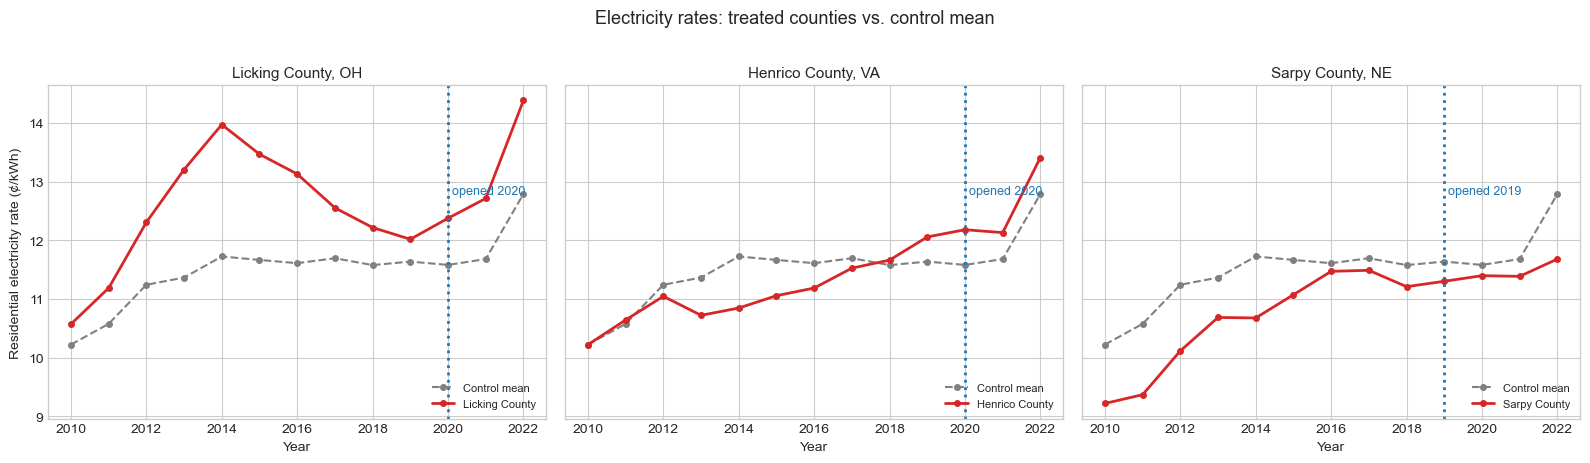

In [2]:
# Residential electricity rate over time: each treated county vs. the control mean
treated = {'39089': ('Licking County, OH', 2020),
           '51087': ('Henrico County, VA', 2020),
           '31153': ('Sarpy County, NE', 2019)}

clean = df[df['contaminated_control'] != 1].copy()
control_mean = (clean[clean['is_treated'] == 0]
                .groupby('year')['elec_rate_cents_kwh'].mean())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (fips, (name, open_yr)) in zip(axes, treated.items()):
    t = df[df['fips'] == fips].sort_values('year')
    ax.plot(control_mean.index, control_mean.values, '--o', color='gray',
            ms=4, lw=1.5, label='Control mean')
    ax.plot(t['year'], t['elec_rate_cents_kwh'], '-o', color='tab:red',
            ms=4, lw=2, label=name.split(',')[0])
    ax.axvline(open_yr, color='tab:blue', ls=':', lw=2)
    ax.annotate(f'opened {open_yr}', xy=(open_yr, ax.get_ylim()[1]),
                xytext=(open_yr + 0.1, control_mean.max()),
                fontsize=9, color='tab:blue')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8, loc='lower right')
axes[0].set_ylabel('Residential electricity rate (¢/kWh)')
fig.suptitle('Electricity rates: treated counties vs. control mean', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'treated_vs_control_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Methodology

We use linear regression because all three outcomes are continuous and we want to pull out the piece of the variation that tracks with a data center opening, holding the rest of the county's characteristics fixed. Year fixed effects soak up anything that hit every county in a given year (the business cycle, COVID), and state fixed effects soak up the baseline differences between Ohio, Nebraska, and Virginia.

We fit five models, each one adding more controls than the last. The point is to watch whether the treatment estimate holds steady as we account for more of what's going on economically:

- **M1, baseline:** treatment plus year and state fixed effects, nothing else.
- **M2:** adds the economic controls, income, employment, wages, electricity price.
- **M3:** adds poverty, unemployment, population density, age, and education.
- **M4:** the M3 variables, fit with Lasso (which drops variables it doesn't need).
- **M5:** the M3 variables, fit with Ridge (which shrinks coefficients instead of dropping them).

Every model gets scored with 10-fold cross-validation, with the folds split by county (`GroupKFold` on `fips`). Splitting by county matters: it keeps any single county entirely in training or entirely in test, never both, so the error estimate reflects how well the model does on counties it has never seen. We rank the models by cross-validated RMSE.

One more thing on the standard errors. A county appears 13 times in the data, once per year, and those repeat observations move together, so plain standard errors would make us look more certain than we are. Clustering the standard errors on county fixes that, and these are the intervals we use whenever we talk about the treatment effect.

## Model specifications

Each model predicts one outcome at a time. If a control variable happens to be the thing we're predicting, we leave it out of that model's predictors.

| Component | M1 | M2 | M3 | M4 | M5 |
|---|:--:|:--:|:--:|:--:|:--:|
| `dc_active` (treatment) | ✓ | ✓ | ✓ | ✓ | ✓ |
| Year fixed effects | ✓ | ✓ | ✓ | ✓ | ✓ |
| State fixed effects | ✓ | ✓ | ✓ | ✓ | ✓ |
| Per-capita income | | ✓ | ✓ | ✓ | ✓ |
| Log total employment | | ✓ | ✓ | ✓ | ✓ |
| Average annual wage | | ✓ | ✓ | ✓ | ✓ |
| Electricity rate | | ✓ | ✓ | ✓ | ✓ |
| Poverty rate | | | ✓ | ✓ | ✓ |
| Unemployment rate | | | ✓ | ✓ | ✓ |
| Log population density | | | ✓ | ✓ | ✓ |
| Median age | | | ✓ | ✓ | ✓ |
| % bachelor's degree | | | ✓ | ✓ | ✓ |
| Estimator | OLS | OLS | OLS | Lasso | Ridge |

M4 and M5 run on the same variables as M3, just with regularization. When we quote the treatment effect for those two, we use the plain OLS estimate (with clustered standard errors) on the M3 variables, so the number is comparable to the other models rather than being shrunk by the penalty.

In [3]:
# Comparison across all 5 models and 3 outcomes (winners highlighted)
label = {'elec_rate_cents_kwh': 'Electricity rate (¢/kWh)',
         'unemployment_rate': 'Unemployment rate (pp)',
         'per_capita_income': 'Per-capita income ($)'}

display_cols = ['outcome', 'model', 'n_obs', 'cv_rmse',
                'dc_active_coef_ols', 'dc_active_ci_lo_ols', 'dc_active_ci_hi_ols',
                'is_winner']
tbl = results[display_cols].copy()
tbl['outcome'] = tbl['outcome'].map(label)

(tbl.style
    .format({'cv_rmse': '{:.3f}', 'dc_active_coef_ols': '{:.3f}',
             'dc_active_ci_lo_ols': '{:.3f}', 'dc_active_ci_hi_ols': '{:.3f}'})
    .apply(lambda r: ['background-color: lightgreen' if r['is_winner'] else ''
                      for _ in r], axis=1)
    .set_caption('Model comparison — treatment coefficient with cluster-robust 95% CI'))

,outcome,model,n_obs,cv_rmse,dc_active_coef_ols,dc_active_ci_lo_ols,dc_active_ci_hi_ols,is_winner
0,Electricity rate (¢/kWh),M1,2757,0.847,0.519,0.264,0.774,False
1,Electricity rate (¢/kWh),M2,2757,0.828,0.916,0.532,1.300,False
2,Electricity rate (¢/kWh),M3,2757,0.823,0.892,0.481,1.303,True
3,Electricity rate (¢/kWh),M4,2757,0.826,0.892,0.481,1.303,False
4,Electricity rate (¢/kWh),M5,2757,0.826,0.892,0.481,1.303,False
5,Unemployment rate (pp),M1,2757,1.179,-0.125,-0.762,0.512,False
6,Unemployment rate (pp),M2,2757,1.074,0.295,-0.418,1.008,False
7,Unemployment rate (pp),M3,2757,0.976,0.588,0.013,1.163,True
8,Unemployment rate (pp),M4,2757,0.976,0.588,0.013,1.163,False
9,Unemployment rate (pp),M5,2757,1.005,0.588,0.013,1.163,False


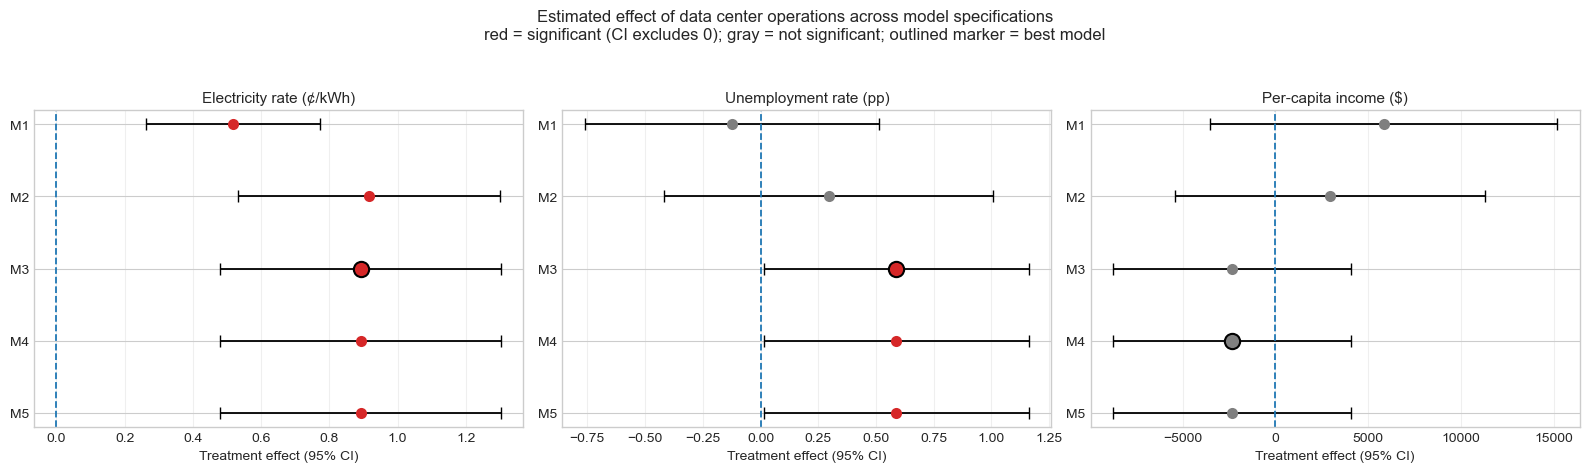

In [4]:
# Treatment effect (dc_active) with 95% cluster-robust CIs across models
outcomes = ['elec_rate_cents_kwh', 'unemployment_rate', 'per_capita_income']
order = ['M1', 'M2', 'M3', 'M4', 'M5']

def excludes_zero(lo, hi):
    return (lo > 0 and hi > 0) or (lo < 0 and hi < 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, oc in zip(axes, outcomes):
    sub = results[results['outcome'] == oc].set_index('model').loc[order]
    yy = np.arange(len(order))[::-1]
    coefs = sub['dc_active_coef_ols'].values
    lo = sub['dc_active_ci_lo_ols'].values
    hi = sub['dc_active_ci_hi_ols'].values
    ax.errorbar(coefs, yy, xerr=[coefs - lo, hi - coefs], fmt='none',
                ecolor='black', elinewidth=1.3, capsize=4)
    for x, y, l, h, w in zip(coefs, yy, lo, hi, sub['is_winner'].values):
        color = 'tab:red' if excludes_zero(l, h) else 'tab:gray'
        ax.plot(x, y, 'o', ms=11 if w else 8, color=color, zorder=3,
                markeredgecolor='black' if w else 'none', markeredgewidth=1.5)
    ax.axvline(0, color='tab:blue', ls='--', lw=1.3)
    ax.set_yticks(yy); ax.set_yticklabels(order)
    ax.set_title(label[oc], fontsize=11)
    ax.set_xlabel('Treatment effect (95% CI)')
    ax.grid(axis='x', alpha=0.3)
fig.suptitle('Estimated effect of data center operations across model specifications\n'
             'red = significant (CI excludes 0); gray = not significant; '
             'outlined marker = best model', fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(FIG / 'dc_active_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

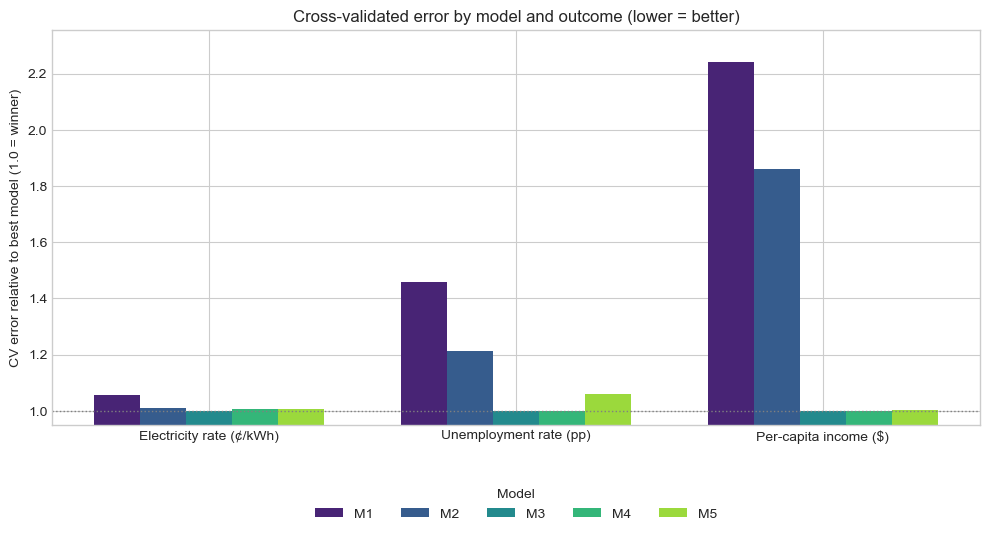

In [5]:
# Cross-validated error by model and outcome (normalized within each outcome,
# since the three outcomes live on very different scales). 1.0 = best model.
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(order)))
x = np.arange(len(outcomes)); bw = 0.15
for mi, m in enumerate(order):
    heights = []
    for oc in outcomes:
        s = results[results['outcome'] == oc]
        val = s[s['model'] == m]['cv_mse_mean'].iloc[0]
        heights.append(val / s['cv_mse_mean'].min())
    ax.bar(x + mi * bw, heights, bw, label=m, color=colors[mi])
ax.set_xticks(x + bw * (len(order) - 1) / 2)
ax.set_xticklabels([label[o] for o in outcomes])
ax.set_ylabel('CV error relative to best model (1.0 = winner)')
ax.set_title('Cross-validated error by model and outcome (lower = better)')
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_ylim(0.95, max(1.05, ax.get_ylim()[1]))
ax.legend(title='Model', ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.13))
plt.tight_layout()
plt.savefig(FIG / 'cv_mse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## What we found

**Electricity rates are the real story here.** In all five models, opening a data center lines up with a residential electricity rate that's about **0.89 ¢/kWh higher** (95% CI [0.48, 1.30]) in the years after it starts running. Average rates in our sample sit around 11.5 ¢/kWh, so that's roughly a 7 to 8 percent bump. What makes us trust it is that the effect shows up everywhere, in the stripped-down M1 and in the fully loaded M3 alike, so it isn't riding on one particular choice of controls.

**Unemployment is murkier.** The estimate is about **0.59 percentage points higher** (M3, our best model, 95% CI [0.013, 1.16]). But it only clears statistical significance in the richer models (M3, M4, M5), and even then the bottom of the interval is basically sitting on zero. We'd call this a hint of a labor-market effect worth a closer look, not something we'd stake a claim on.

**Income shows nothing.** No detectable effect on per-capita income (M4, β = **−$2,353**, 95% CI [−$8,755, $4,049]). The sign actually flips, positive (+$5,837) in M1 and negative once we add controls. That's the controls doing their job: the counties that land data centers were already economically different from the ones that didn't, and once you account for those starting differences, there's no income effect left to see.

## Caveats

A few things we want to be upfront about.

Only three counties are actually treated. That's the big one. With so few treated units the estimates are jumpy and the intervals are wide, and clustering the standard errors can't conjure precision that three counties simply don't provide. The electricity result holds up across every specification, which is reassuring, but it's still three counties at the end of the day.

The post-period (2019 to 2022) sits right on top of COVID. Year fixed effects pull out whatever the pandemic did to all counties at once, which is the standard fix, but if the pandemic hit treated counties differently than the rest, that would still be in there.

Sarpy County is a compound case. It picked up more than one operator over the window, so its "treatment" is really combined data center activity, not a clean single-company signal. That's part of why we keep the language general.

Finally, we're after the treatment effect, not the best possible prediction. Cross-validation is just our yardstick for comparing the five models fairly. Because controls vastly outnumber treated counties, the CV error is mostly telling us how well we predict ordinary control counties; the treatment number itself comes from the full-data fit with clustered standard errors.

## Discussion and policy implications

The cleanest finding is on cost. A 7 to 8 percent rise in residential electricity rates after a data center opens fits the cost pass-through story pretty naturally: these campuses pull a huge, concentrated load, and the price of building and running the generation and grid capacity to feed them can land on the bills of regular households in the same service territory.

And on the other side of the ledger, we don't see a local payoff. Income doesn't budge once you account for baseline differences, and the unemployment estimate, if it's pointing anywhere, points the wrong way. That tracks with how these facilities work, they're enormously capital-intensive but run with a skeleton crew, so a jump in local income or jobs was never guaranteed.

Put those together and you get a real question for the communities weighing these projects. If the local upside is thin and residents may be the ones absorbing higher utility costs, there's a strong case for negotiating something concrete up front, rate protections, host fees, infrastructure money, instead of approving a campus on the assumption that prosperity follows.

## Where this could go next

Some directions we'd chase with more time:

The obvious gap is environmental data. These campuses drink water and electricity, and pulling in water-use and air-quality numbers would round out the picture well beyond the three economic outcomes we looked at.

The post-period is also short. A few of these campuses only opened in 2019 or 2020, so we're watching a narrow window; the estimates will sharpen on their own as more years roll in.

More than anything, the study needs more treated counties. Going national instead of three states would multiply the treated units and tighten the intervals a lot. And once you have that, you could actually model the multi-operator counties like Sarpy on purpose and tease apart single-operator from multi-operator effects.